# 6. Порівняльний аналіз класифікаторів

Порівнюємо 4 класифікатори (OneR, Naive Bayes, Decision Tree, kNN) на 3 ознаках датасету Adult Census Income.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
from mlxtend.classifier import OneRClassifier
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('data_processed.csv')
X = df[['age', 'education-num', 'relationship']]
y = df['income']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Train: 39073, Test: 9769


In [2]:
results = {}

def evaluate(name, y_true, y_pred):
    results[name] = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1': f1_score(y_true, y_pred, zero_division=0)
    }

# 1) OneR — дискретизація age на 5 бінів
bins = np.linspace(X_train['age'].min(), X_train['age'].max(), 6)
X_tr_d = X_train.copy()
X_te_d = X_test.copy()
X_tr_d['age'] = np.digitize(X_train['age'], bins[1:-1])
X_te_d['age'] = np.digitize(X_test['age'], bins[1:-1])

oner = OneRClassifier()
oner.fit(X_tr_d.values, y_train.values)
evaluate('OneR', y_test, oner.predict(X_te_d.values))

# 2) Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
evaluate('Naive Bayes', y_test, nb.predict(X_test))

# 3) Decision Tree
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
evaluate('Decision Tree', y_test, dt.predict(X_test))

# 4) kNN
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train_sc, y_train)
evaluate('kNN', y_test, knn.predict(X_test_sc))

print('Всі класифікатори навчено.')

Всі класифікатори навчено.


## Зведена таблиця результатів

In [3]:
comp_df = pd.DataFrame(results).T.round(4)
comp_df

,Accuracy,Precision,Recall,F1
OneR,0.7840,0.6439,0.2181,0.3259
Naive Bayes,0.8073,0.6707,0.3832,0.4878
Decision Tree,0.8267,0.6531,0.5885,0.6191
kNN,0.8085,0.6121,0.5453,0.5768


## Порівняння метрик (стовпчикова діаграма)

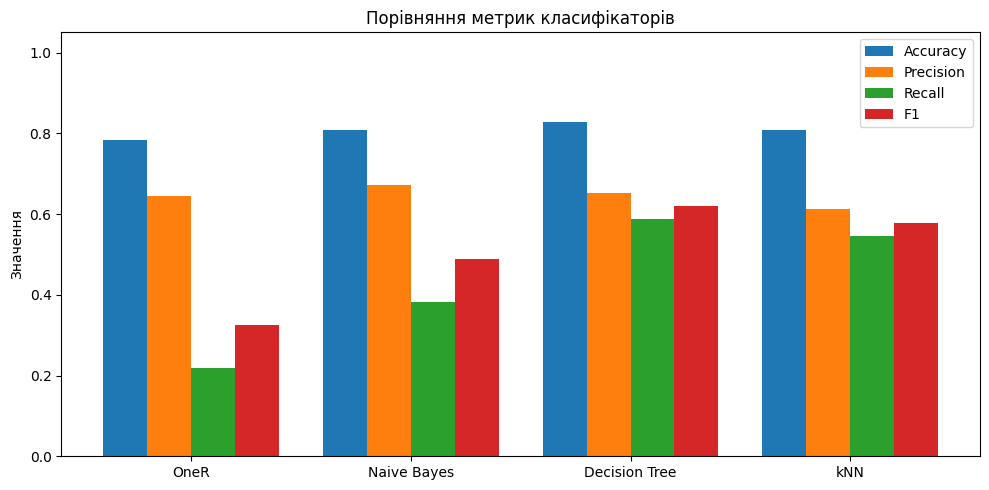

In [4]:
names = list(results.keys())
metrics = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(names))
w = 0.2

fig, ax = plt.subplots(figsize=(10, 5))
for i, m in enumerate(metrics):
    vals = [results[n][m] for n in names]
    ax.bar(x + i * w, vals, w, label=m)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(names)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Значення')
ax.set_title('Порівняння метрик класифікаторів')
ax.legend()
plt.tight_layout()
plt.show()

## Матриці помилок

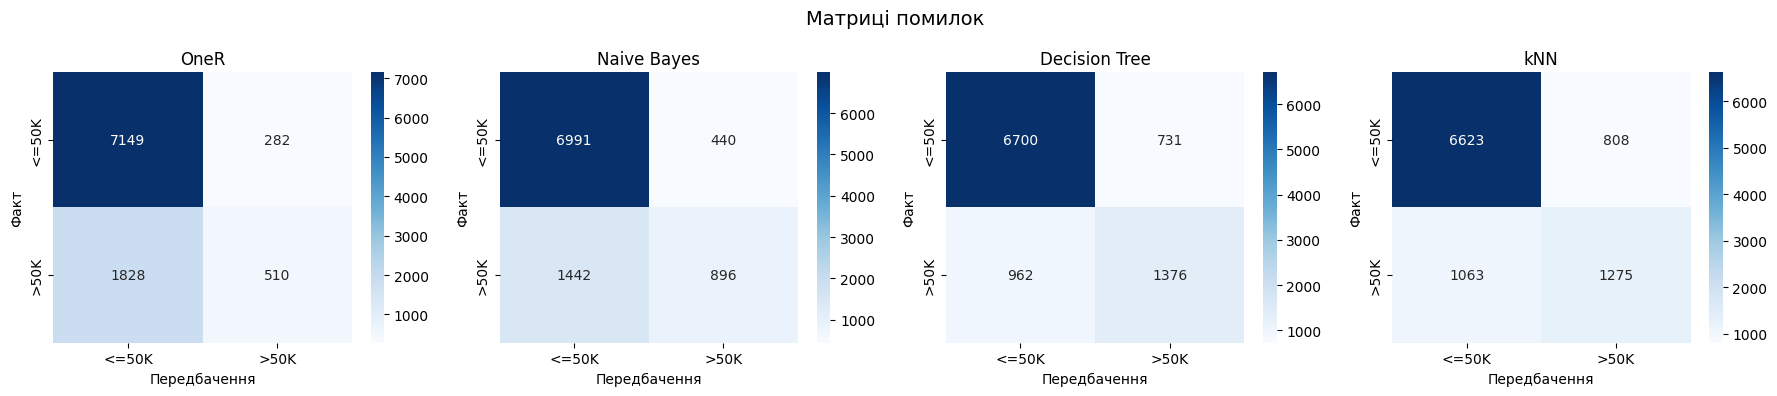

In [5]:
models_pred = {
    'OneR': oner.predict(X_te_d.values),
    'Naive Bayes': nb.predict(X_test),
    'Decision Tree': dt.predict(X_test),
    'kNN': knn.predict(X_test_sc)
}

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (name, y_pred) in zip(axes, models_pred.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
    ax.set_title(name)
    ax.set_xlabel('Передбачення')
    ax.set_ylabel('Факт')
plt.suptitle('Матриці помилок', fontsize=14)
plt.tight_layout()
plt.show()

## ROC-криві

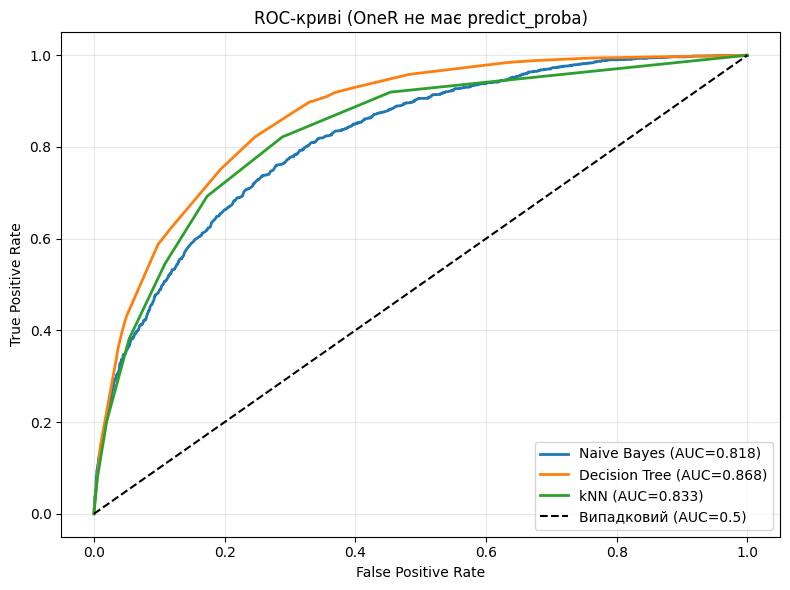

In [6]:
plt.figure(figsize=(8, 6))

for name, model, X_te in [('Naive Bayes', nb, X_test),
                           ('Decision Tree', dt, X_test),
                           ('kNN', knn, X_test_sc)]:
    proba = model.predict_proba(X_te)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC={auc(fpr, tpr):.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Випадковий (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-криві (OneR не має predict_proba)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Висновки

| Класифікатор | Переваги | Недоліки | Коли використовувати |
|---|---|---|---|
| **OneR** | Простий, швидкий, інтерпретований | Лише 1 ознака, низька якість | Baseline для порівняння |
| **Naive Bayes** | Швидкий, працює з малими вибірками | Припущення незалежності порушується | Прототипування, текстові дані |
| **Decision Tree** | Інтерпретований, не потребує масштабування | Може перенавчатися | Коли важливо пояснити рішення |
| **kNN** | Нелінійні межі, простий | Повільний на великих даних | Невеликі датасети з малою кількістю ознак |

### Ключові спостереження

- Молоді неодружені люди з низькою освітою -- найчастіше заробляють <=50K
- Одружені люди 35-55 років з вищою освітою (Bachelors+) -- найчастіше >50K
- Decision Tree та kNN показують найкращі результати
- OneR -- корисний baseline, але використовує лише 1 атрибут
- Naive Bayes програє через порушення припущення про незалежність (вік і сімейний стан корелюють)